# 00 — General Behaviour Quality Check

Cohort overview table, plus single-animal session timelines and learning trajectories.

## Setup

In [5]:
%matplotlib inline
from shared_setup import *
from plotting.overview import plot_timeline

experiment, info = load_data()
print(f"Mode: {info['mode']}")

Loaded snapshot: 22 animals, 1185 sessions (exported 2026-06-09)
Mode: snapshot


/Users/Serkan/Desktop/pro/PhD/main/repos/sound_categorisation/notebooks/shared_setup.py:193: UserWarning: Snapshot is 215h old (exported 2026-06-09T12:49:35.485965+00:00). Re-export if new sessions have been collected.
  experiment, meta = load_snapshot(


## Cohort overview

In [6]:
rows = []
for aid, animal in sorted(experiment.animals.items()):
    table = animal.session_table
    types = dict(table.session_type.value_counts())
    dists = dict(table.distribution.value_counts())
    rows.append({
        'animal_id': aid, 'genotype': animal.genotype,
        'n_sessions': len(table),
        'n_uniform': dists.get('Uniform', 0),
        'n_hard_a': dists.get('Hard-A', 0),
        'n_hard_b': dists.get('Hard-B', 0),
        'regular': types.get('regular', 0),
        'masking': types.get('masking', 0),
        'opto': types.get('opto', 0),
        'washout': types.get('washout', 0),
    })
cohort_df = pd.DataFrame(rows)
print(cohort_df.to_string(index=False))

animal_id genotype  n_sessions  n_uniform  n_hard_a  n_hard_b  regular  masking  opto  washout
     SS01      het          81         46        13        22       81        0     0        0
     SS02      het          20         20         0         0       20        0     0        0
     SS04      het         100         63        13        22      100        0     0        0
     SS05      het          73         38        13        22       73        0     0        0
     SS06      het          72         37        13        22       72        0     0        0
     SS07      het          73         38        13        22       73        0     0        0
     SS08      het          73         42        13        18       73        0     0        0
     SS09      het          63         29        12        22       63        0     0        0
     SS10      het          63         63         0         0       63        0     0        0
     SS11      het          63         31        1

## Single animal — timeline & trajectory

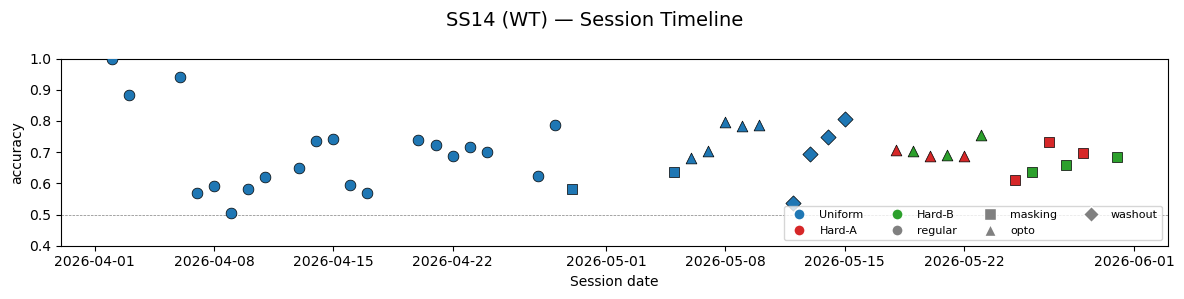

In [7]:
animal_id = 'SS14'
animal = experiment.get_animal(animal_id)

fig = plot_timeline(animal, stat='accuracy', x_axis='date', ylim=(0.4, 1.0), hline=0.5)

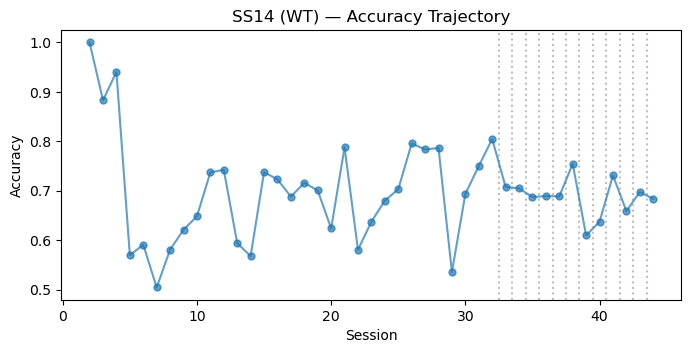

In [8]:
trajectories = compute_trajectory(animal, stat_names=['accuracy'])
fig = plot_trajectory(trajectories, stat_name='accuracy',
                      title=f'{animal_id} ({animal.genotype.upper()}) — Accuracy Trajectory')